# 🤖 AI-Based Autonomous Navigation System
## Path Analysis Notebook

This notebook visualizes the A* path planning algorithm used in the navigation system.

**Modules covered:**
- Grid environment creation
- A* path planning
- Path visualization
- Performance analysis


---
## 📦 Step 1 — Install & Import Libraries

In [1]:
# Run this cell first to install required libraries
# (Skip if already installed)
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import heapq
import random
import time
import csv
import os

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## ⚙️ Step 2 — Configuration Settings
Adjust these values to experiment with different grid sizes and obstacle densities.

In [3]:
# ── CONFIGURATION ──────────────────────────────────────────
GRID_ROWS        = 20       # Number of rows in the grid
GRID_COLS        = 20       # Number of columns in the grid
OBSTACLE_DENSITY = 0.25     # 0.0 = no obstacles, 1.0 = all obstacles
RANDOM_SEED      = 42       # Change seed to get a different map

print(f"Grid size      : {GRID_ROWS} x {GRID_COLS}")
print(f"Obstacle density: {OBSTACLE_DENSITY * 100:.0f}%")
print(f"Random seed    : {RANDOM_SEED}")

Grid size      : 20 x 20
Obstacle density: 25%
Random seed    : 42


---
## 🗺️ Step 3 — Create the Grid Environment

In [4]:
def create_grid(rows, cols, obstacle_density, seed=42):
    """
    Creates a 2D grid:
      0 = free cell
      1 = obstacle
    """
    random.seed(seed)
    grid = np.zeros((rows, cols), dtype=int)
    for r in range(rows):
        for c in range(cols):
            if random.random() < obstacle_density:
                grid[r][c] = 1
    return grid


def place_start_goal(grid, rows, cols):
    """Forces start=(0,0) and goal=(rows-1,cols-1) to be free."""
    start = (0, 0)
    goal  = (rows - 1, cols - 1)
    grid[start[0]][start[1]] = 0
    grid[goal[0]][goal[1]]   = 0
    return start, goal


def get_neighbors(node, grid, rows, cols):
    """Returns valid free neighboring cells (4-directional)."""
    r, c = node
    neighbors = []
    for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        nr, nc = r + dr, c + dc
        if 0 <= nr < rows and 0 <= nc < cols and grid[nr][nc] == 0:
            neighbors.append((nr, nc))
    return neighbors


# ── Create grid ─────────────────────────────────────────────
grid = create_grid(GRID_ROWS, GRID_COLS, OBSTACLE_DENSITY, RANDOM_SEED)
start, goal = place_start_goal(grid, GRID_ROWS, GRID_COLS)

obstacle_count = int(np.sum(grid))
free_count     = GRID_ROWS * GRID_COLS - obstacle_count

print(f"Start position : {start}")
print(f"Goal  position : {goal}")
print(f"Free  cells    : {free_count}")
print(f"Obstacle cells : {obstacle_count}")

Start position : (0, 0)
Goal  position : (19, 19)
Free  cells    : 297
Obstacle cells : 103


C:\Users\chowd\AppData\Local\Temp\ipykernel_10364\1294967409.py:31: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=[1.0, 1.0, 1.0],  label='Free Cell',


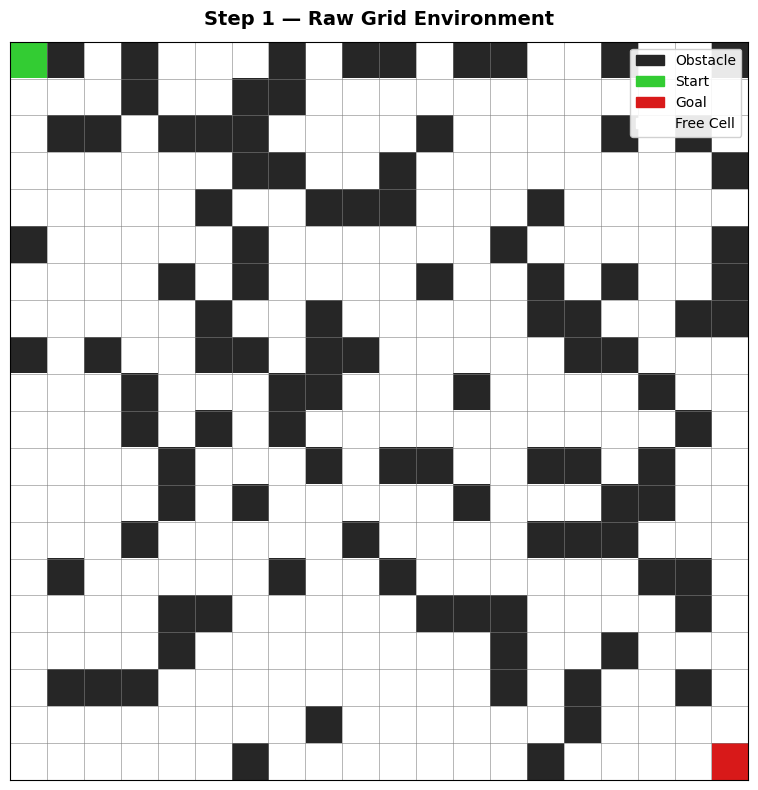

📸 Saved → images/01_raw_grid.png


In [5]:
# ── Visualize raw grid (before path planning) ───────────────
def plot_grid_raw(grid, start, goal, title="Grid Environment"):
    rows, cols = grid.shape
    display = np.ones((rows, cols, 3))

    for r in range(rows):
        for c in range(cols):
            if grid[r][c] == 1:
                display[r, c] = [0.15, 0.15, 0.15]   # obstacle — dark

    display[start[0], start[1]] = [0.20, 0.80, 0.20]  # start — green
    display[goal[0],  goal[1]]  = [0.85, 0.10, 0.10]  # goal  — red

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(display, interpolation='nearest')

    # Grid lines
    for x in range(cols + 1):
        ax.axvline(x - 0.5, color='gray', linewidth=0.4)
    for y in range(rows + 1):
        ax.axhline(y - 0.5, color='gray', linewidth=0.4)

    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.set_xticks([])
    ax.set_yticks([])

    legend = [
        mpatches.Patch(color=[0.15,0.15,0.15], label='Obstacle'),
        mpatches.Patch(color=[0.20,0.80,0.20], label='Start'),
        mpatches.Patch(color=[0.85,0.10,0.10], label='Goal'),
        mpatches.Patch(color=[1.0, 1.0, 1.0],  label='Free Cell',
                       linewidth=1, edgecolor='gray'),
    ]
    ax.legend(handles=legend, loc='upper right',
              fontsize=10, framealpha=0.9)

    plt.tight_layout()
    os.makedirs("images", exist_ok=True)
    plt.savefig("images/01_raw_grid.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("📸 Saved → images/01_raw_grid.png")


plot_grid_raw(grid, start, goal, title="Step 1 — Raw Grid Environment")

---
## 🧭 Step 4 — A* Path Planning Algorithm

In [6]:
def heuristic(a, b):
    """Manhattan distance — admissible heuristic for 4-directional grids."""
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def astar(grid, start, goal, rows, cols):
    """
    A* search algorithm.
    Returns:
        path    : list of (row, col) from start to goal, or None
        visited : set of all explored cells
        g_scores: dict of actual cost from start to each cell
    """
    open_set = []
    heapq.heappush(open_set, (0, start))

    came_from = {}
    g_score   = {start: 0}
    f_score   = {start: heuristic(start, goal)}
    visited   = set()
    counter   = 0   # tie-breaker for equal f-scores

    while open_set:
        _, current = heapq.heappop(open_set)

        if current in visited:
            continue
        visited.add(current)

        if current == goal:
            # Reconstruct path
            path = []
            node = current
            while node in came_from:
                path.append(node)
                node = came_from[node]
            path.append(start)
            path.reverse()
            return path, visited, g_score

        for neighbor in get_neighbors(current, grid, rows, cols):
            tentative_g = g_score[current] + 1
            if tentative_g < g_score.get(neighbor, float('inf')):
                came_from[neighbor] = current
                g_score[neighbor]   = tentative_g
                f                   = tentative_g + heuristic(neighbor, goal)
                counter            += 1
                heapq.heappush(open_set, (f, neighbor))

    return None, visited, g_score


# ── Run A* ──────────────────────────────────────────────────
t0 = time.perf_counter()
path, visited, g_scores = astar(grid, start, goal, GRID_ROWS, GRID_COLS)
elapsed_ms = (time.perf_counter() - t0) * 1000

if path:
    print(f"✅ Path FOUND!")
    print(f"   Path length      : {len(path)} cells")
    print(f"   Cells explored   : {len(visited)}")
    print(f"   Planning time    : {elapsed_ms:.3f} ms")
    print(f"   Efficiency ratio : {len(path)/len(visited)*100:.1f}%  "
          f"(path / explored)")
else:
    print("❌ No path found. Try reducing OBSTACLE_DENSITY in Step 2.")

✅ Path FOUND!
   Path length      : 39 cells
   Cells explored   : 131
   Planning time    : 0.385 ms
   Efficiency ratio : 29.8%  (path / explored)


---
## 📊 Step 5 — Visualize A* Exploration + Optimal Path

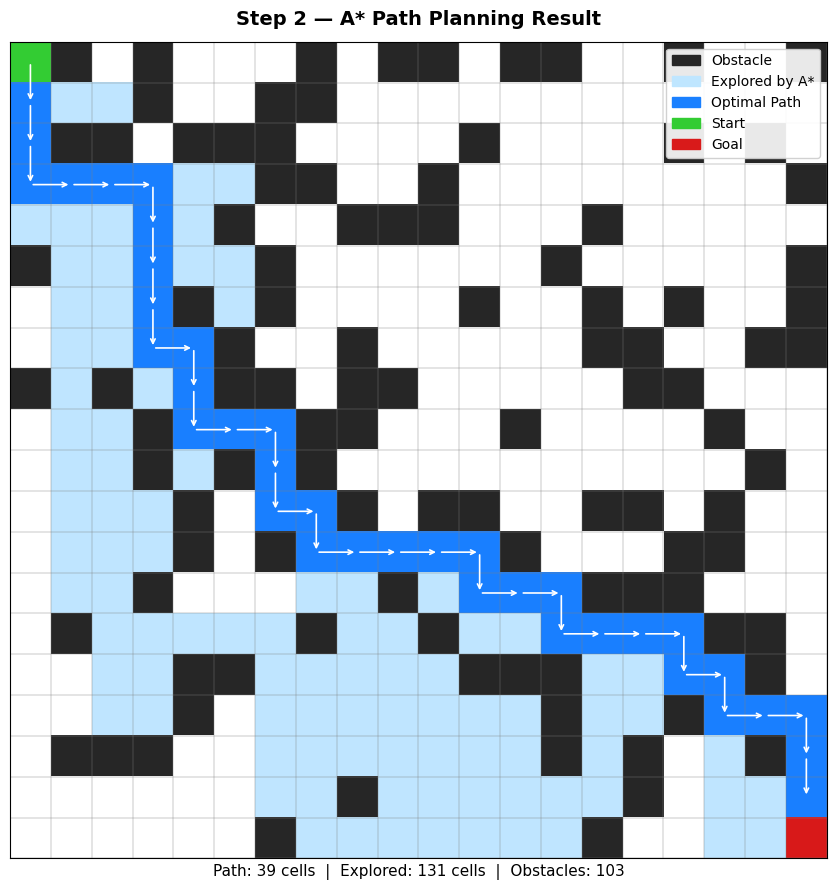

📸 Saved → images/02_astar_result.png


In [7]:
def plot_astar_result(grid, start, goal, path, visited, title="A* Path Planning Result"):
    rows, cols = grid.shape
    display    = np.ones((rows, cols, 3))

    # 1. Obstacles
    for r in range(rows):
        for c in range(cols):
            if grid[r][c] == 1:
                display[r, c] = [0.15, 0.15, 0.15]

    # 2. Explored (visited) cells
    for (r, c) in visited:
        if grid[r][c] == 0:
            display[r, c] = [0.75, 0.90, 1.00]   # light blue

    # 3. Optimal path
    if path:
        for (r, c) in path:
            display[r, c] = [0.10, 0.50, 1.00]   # strong blue

    # 4. Start & Goal
    display[start[0], start[1]] = [0.20, 0.80, 0.20]
    display[goal[0],  goal[1]]  = [0.85, 0.10, 0.10]

    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(display, interpolation='nearest')

    # Draw path arrows
    if path:
        for i in range(1, len(path) - 1):
            pr, pc = path[i - 1]
            cr, cc = path[i]
            ax.annotate("",
                xy=(cc, cr), xytext=(pc, pr),
                arrowprops=dict(arrowstyle="->", color="white",
                                lw=1.2, mutation_scale=8))

    # Grid lines
    for x in range(cols + 1):
        ax.axvline(x - 0.5, color='gray', linewidth=0.3)
    for y in range(rows + 1):
        ax.axhline(y - 0.5, color='gray', linewidth=0.3)

    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.set_xticks([])
    ax.set_yticks([])

    path_len = len(path) if path else 0
    info = (f"Path: {path_len} cells  |  "
            f"Explored: {len(visited)} cells  |  "
            f"Obstacles: {int(np.sum(grid))}")
    ax.set_xlabel(info, fontsize=11)

    legend = [
        mpatches.Patch(color=[0.15,0.15,0.15], label='Obstacle'),
        mpatches.Patch(color=[0.75,0.90,1.00], label='Explored by A*'),
        mpatches.Patch(color=[0.10,0.50,1.00], label='Optimal Path'),
        mpatches.Patch(color=[0.20,0.80,0.20], label='Start'),
        mpatches.Patch(color=[0.85,0.10,0.10], label='Goal'),
    ]
    ax.legend(handles=legend, loc='upper right',
              fontsize=10, framealpha=0.9)

    plt.tight_layout()
    os.makedirs("images", exist_ok=True)
    plt.savefig("images/02_astar_result.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("📸 Saved → images/02_astar_result.png")


plot_astar_result(grid, start, goal, path, visited,
                  title="Step 2 — A* Path Planning Result")

---
## 🚶 Step 6 — Animate Agent Navigation (Step-by-Step)

In [8]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def animate_navigation(grid, start, goal, path, visited):
    """Creates an inline animation of the agent moving along the path."""
    rows, cols = grid.shape

    # Base display (obstacles + explored)
    base = np.ones((rows, cols, 3))
    for r in range(rows):
        for c in range(cols):
            if grid[r][c] == 1:
                base[r, c] = [0.15, 0.15, 0.15]
    for (r, c) in visited:
        if grid[r][c] == 0:
            base[r, c] = [0.75, 0.90, 1.00]
    if path:
        for (r, c) in path:
            base[r, c] = [0.10, 0.50, 1.00]
    base[start[0], start[1]] = [0.20, 0.80, 0.20]
    base[goal[0],  goal[1]]  = [0.85, 0.10, 0.10]

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xticks([])
    ax.set_yticks([])
    im = ax.imshow(base.copy(), interpolation='nearest')
    title_obj = ax.set_title("Agent Navigation — Step 0", fontsize=13,
                              fontweight='bold')

    def update(frame):
        display = base.copy()
        if frame < len(path):
            ar, ac = path[frame]
            display[ar, ac] = [1.0, 0.84, 0.0]   # agent — gold
            title_obj.set_text(f"Agent Navigation — Step {frame} / {len(path)-1}")
        else:
            ar, ac = goal
            display[ar, ac] = [0.0, 1.0, 0.5]    # reached — bright green
            title_obj.set_text("✅ Goal Reached!")
        im.set_data(display)
        return [im, title_obj]

    anim = FuncAnimation(
        fig, update,
        frames=len(path) + 5,  # extra frames to hold final state
        interval=120,
        blit=True
    )

    plt.close(fig)  # prevent double display
    return anim


if path:
    anim = animate_navigation(grid, start, goal, path, visited)
    HTML(anim.to_jshtml())   # renders inside VS Code / Jupyter
else:
    print("⚠️  No path to animate.")

C:\Users\chowd\AppData\Local\Temp\ipykernel_10364\3254211645.py:56: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  HTML(anim.to_jshtml())   # renders inside VS Code / Jupyter


---
## 📈 Step 7 — Performance Analysis Charts

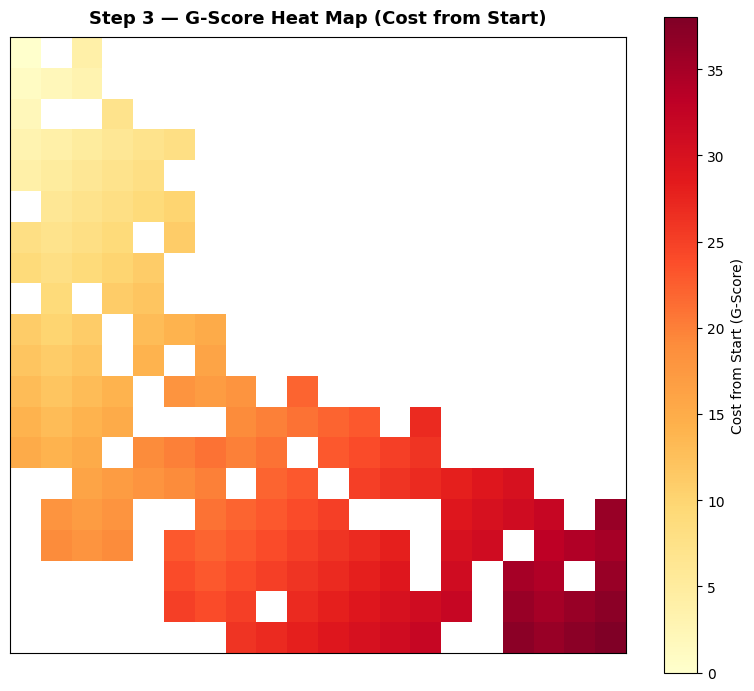

📸 Saved → images/03_gscore_heatmap.png


In [9]:
# ── Chart 1: Heuristic (f-score) heat map ───────────────────
def plot_heuristic_heatmap(grid, goal, g_scores, title="G-Score Heat Map"):
    rows, cols = grid.shape
    heat = np.full((rows, cols), np.nan)

    for (r, c), g in g_scores.items():
        if grid[r][c] == 0:
            heat[r, c] = g

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(heat, cmap='YlOrRd', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Cost from Start (G-Score)')

    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    plt.savefig("images/03_gscore_heatmap.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("📸 Saved → images/03_gscore_heatmap.png")


plot_heuristic_heatmap(grid, goal, g_scores,
                       title="Step 3 — G-Score Heat Map (Cost from Start)")

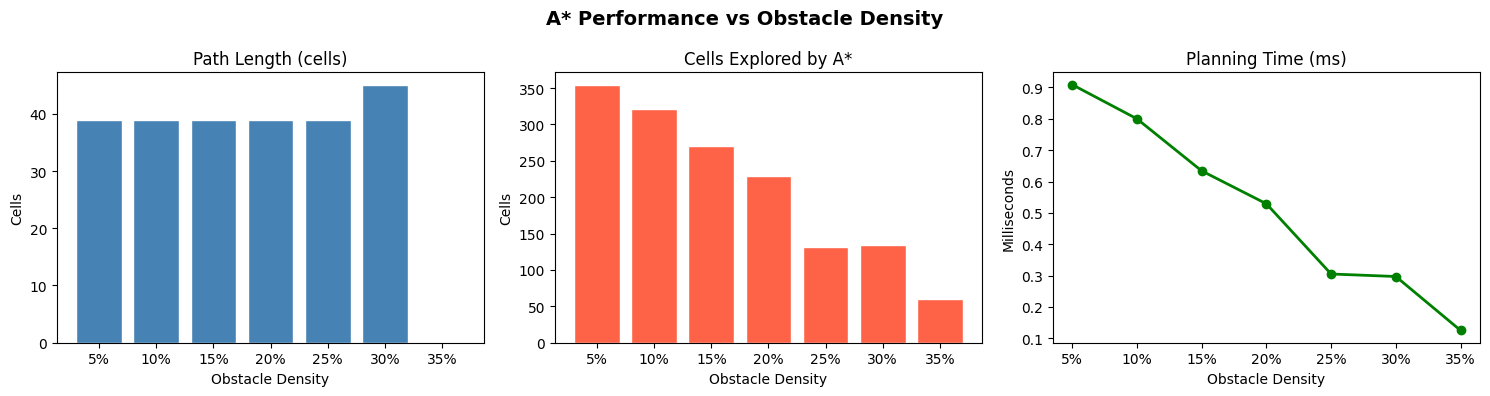

📸 Saved → images/04_benchmark_chart.png


In [10]:
# ── Chart 2: Benchmark — different obstacle densities ────────
densities    = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35]
path_lengths = []
explored_counts = []
times_ms     = []

for d in densities:
    g = create_grid(GRID_ROWS, GRID_COLS, d, seed=RANDOM_SEED)
    s, gl = place_start_goal(g, GRID_ROWS, GRID_COLS)
    t0 = time.perf_counter()
    p, v, _ = astar(g, s, gl, GRID_ROWS, GRID_COLS)
    ms = (time.perf_counter() - t0) * 1000
    path_lengths.append(len(p) if p else 0)
    explored_counts.append(len(v))
    times_ms.append(round(ms, 3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("A* Performance vs Obstacle Density",
             fontsize=14, fontweight='bold')

labels = [f"{int(d*100)}%" for d in densities]

axes[0].bar(labels, path_lengths, color='steelblue', edgecolor='white')
axes[0].set_title("Path Length (cells)")
axes[0].set_xlabel("Obstacle Density")
axes[0].set_ylabel("Cells")

axes[1].bar(labels, explored_counts, color='tomato', edgecolor='white')
axes[1].set_title("Cells Explored by A*")
axes[1].set_xlabel("Obstacle Density")
axes[1].set_ylabel("Cells")

axes[2].plot(labels, times_ms, marker='o', color='green', linewidth=2)
axes[2].set_title("Planning Time (ms)")
axes[2].set_xlabel("Obstacle Density")
axes[2].set_ylabel("Milliseconds")

plt.tight_layout()
plt.savefig("images/04_benchmark_chart.png", dpi=150, bbox_inches='tight')
plt.show()
print("📸 Saved → images/04_benchmark_chart.png")

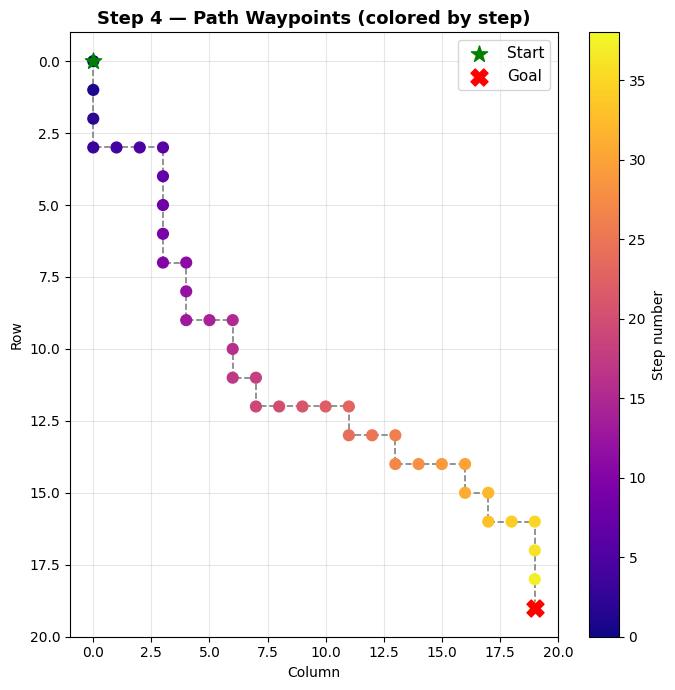

📸 Saved → images/05_path_waypoints.png


In [11]:
# ── Chart 3: Path waypoints scatter plot ─────────────────────
if path:
    path_rows = [p[0] for p in path]
    path_cols = [p[1] for p in path]

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.invert_yaxis()
    scatter = ax.scatter(
        path_cols, path_rows,
        c=range(len(path)), cmap='plasma',
        s=60, zorder=3
    )
    ax.plot(path_cols, path_rows, color='gray',
            linewidth=1.2, zorder=2, linestyle='--')
    plt.colorbar(scatter, ax=ax, label='Step number')

    ax.scatter(path_cols[0],  path_rows[0],  color='green',
               s=150, zorder=4, label='Start', marker='*')
    ax.scatter(path_cols[-1], path_rows[-1], color='red',
               s=150, zorder=4, label='Goal',  marker='X')

    ax.set_xlim(-1, GRID_COLS)
    ax.set_ylim(GRID_ROWS, -1)
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    ax.set_title("Step 4 — Path Waypoints (colored by step)",
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("images/05_path_waypoints.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("📸 Saved → images/05_path_waypoints.png")

---
## 💾 Step 8 — Save Results to CSV

In [12]:
os.makedirs("outputs", exist_ok=True)

# Save waypoints CSV
csv_path = "outputs/path_log.csv"
if path:
    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["step", "row", "col"])
        for i, (r, c) in enumerate(path):
            writer.writerow([i, r, c])
    print(f"✅ Waypoints saved to {csv_path}")

# Save benchmark results CSV
bench_path = "outputs/benchmark_results.csv"
with open(bench_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["obstacle_density_%", "path_length",
                     "cells_explored", "time_ms"])
    for d, pl, ec, tm in zip(densities, path_lengths,
                              explored_counts, times_ms):
        writer.writerow([int(d * 100), pl, ec, tm])
print(f"✅ Benchmark results saved to {bench_path}")

# Save summary text
summary_path = "outputs/results.txt"
with open(summary_path, "w") as f:
    f.write("AI-Based Autonomous Navigation System — Run Summary\n")
    f.write("=" * 50 + "\n")
    f.write(f"Grid size        : {GRID_ROWS} x {GRID_COLS}\n")
    f.write(f"Obstacle density : {OBSTACLE_DENSITY * 100:.0f}%\n")
    f.write(f"Start            : {start}\n")
    f.write(f"Goal             : {goal}\n")
    f.write(f"Path length      : {len(path) if path else 'N/A'} cells\n")
    f.write(f"Cells explored   : {len(visited)}\n")
    f.write(f"Planning time    : {elapsed_ms:.3f} ms\n")
print(f"✅ Summary saved to {summary_path}")

✅ Waypoints saved to outputs/path_log.csv
✅ Benchmark results saved to outputs/benchmark_results.csv
✅ Summary saved to outputs/results.txt


---
## 📋 Step 9 — Final Summary

In [13]:
print("=" * 52)
print("  AI Autonomous Navigation — Notebook Summary")
print("=" * 52)
print(f"  Grid size         : {GRID_ROWS} x {GRID_COLS}")
print(f"  Obstacle density  : {OBSTACLE_DENSITY*100:.0f}%")
print(f"  Start → Goal      : {start} → {goal}")
print(f"  Path found        : {'Yes ✅' if path else 'No ❌'}")
if path:
    print(f"  Path length       : {len(path)} cells")
    print(f"  Cells explored    : {len(visited)}")
    print(f"  Planning time     : {elapsed_ms:.3f} ms")
    eff = len(path) / len(visited) * 100
    print(f"  Efficiency        : {eff:.1f}%  (path / explored)")
print()
print("  Saved images:")
for img in ["01_raw_grid", "02_astar_result",
            "03_gscore_heatmap", "04_benchmark_chart",
            "05_path_waypoints"]:
    print(f"    images/{img}.png")
print()
print("  Saved data:")
print("    outputs/path_log.csv")
print("    outputs/benchmark_results.csv")
print("    outputs/results.txt")
print("=" * 52)

  AI Autonomous Navigation — Notebook Summary
  Grid size         : 20 x 20
  Obstacle density  : 25%
  Start → Goal      : (0, 0) → (19, 19)
  Path found        : Yes ✅
  Path length       : 39 cells
  Cells explored    : 131
  Planning time     : 0.385 ms
  Efficiency        : 29.8%  (path / explored)

  Saved images:
    images/01_raw_grid.png
    images/02_astar_result.png
    images/03_gscore_heatmap.png
    images/04_benchmark_chart.png
    images/05_path_waypoints.png

  Saved data:
    outputs/path_log.csv
    outputs/benchmark_results.csv
    outputs/results.txt


---
## 🔮 What's Next?

| Upgrade | Difficulty |
|---|---|
| Add diagonal movement to A* | ⭐ Easy |
| Add dynamic (moving) obstacles | ⭐⭐ Medium |
| Integrate with Pygame simulation | ⭐⭐ Medium |
| Swap A* with Dijkstra / BFS and compare | ⭐ Easy |
| YOLOv8 real-time obstacle detection | ⭐⭐⭐ Hard |
| ROS 2 deployment on real robot | ⭐⭐⭐⭐ Advanced |

---
*Built as part of the AI-Based Autonomous Navigation System project.*